In [95]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import func_plot as fp
import seaborn as sns
import nibabel as nib
from scipy.stats import norm
atlas = nib.load('./BD-SCZ/Schaefer2018_400Parcels_7Networks_order.dlabel.nii').get_fdata()[0]
atlas.shape

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


(64984,)

# Gradients Parcelwise PLS

In [96]:
"""
Partial Least Squares (PLS) pipeline for cortical gradient–behavior relationships.

This script:
1. Loads gradient CSVs (one per gradient).
2. Filters to patient groups (diagnosis 2 = bipolar, 3 = schizophrenia).
3. Encodes categorical vars numerically (gender, diagnosis).
4. Z-scores individual cognitive tests before averaging into domains.
5. Inverts cognitive domain scores (higher = worse performance).
6. Regresses out age and gender from brain features (X).
7. Z-scores both X and Y before PLS.
8. Fits PLS and extracts saliences (x_weights_, y_weights_), scores, and behavior–LV correlations.
9. Stores results in a dictionary and prints summaries.

"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# ------------------------
# Define cortical gradients
# ------------------------
grad_files = ['./g1_aligned_cog.csv', './g2_aligned_cog.csv', './g3_aligned_cog.csv']
grad_names = ['G1', 'G2', 'G3']

# ------------------------
# Define variable groups
# ------------------------
group_definitions = {
    'Attention_WorkingMemory': ['Digit_span_forward', 'Digit_span_backward',
                                'Digit_span_sequencing', 'Letter_number_sequencing'],
    'VerbalLearning_Memory': ['Long_free_recall', 'Short_free_recall', 'Free_recall_correct'],
    'Reasoning_ProblemSolving': ['Matrix_Reasoning'],
    'Verbal_Comprehension': ['Vocabulary']
}

# Clinical + demographic variables to include
other_vars = ['diagnosis', 'SAPSDisorganization', 'Amotivation', 'DimEx',
              'SAPSPositiveSymptoms', 'hamilton_21', 'YMRS']

# Covariates to regress out from brain features
covariate_cols = ['age', 'gender']

# ------------------------
# Helper functions
# ------------------------

def ensure_numeric_encoding(df, col):
    """Ensure categorical columns (e.g., gender) are numeric."""
    if not np.issubdtype(df[col].dtype, np.number):
        mapping = {k: i for i, k in enumerate(df[col].unique())}
        print(f"Auto-mapped '{col}': {mapping}")
        df[col] = df[col].map(mapping)
    return df


def regress_out(X, covariates):
    """
    Regress out confounding variables (e.g., age, gender) from each column of X.
    X: n × p data matrix
    covariates: n × k matrix of confound variables
    """
    X_resid = np.zeros_like(X)
    for j in range(X.shape[1]):
        model = LinearRegression().fit(covariates, X[:, j])
        X_resid[:, j] = X[:, j] - model.predict(covariates)
    return X_resid


# ------------------------
# Main analysis
# ------------------------
results = {}

for grad_file, grad_name in zip(grad_files, grad_names):
    print(f"\n--- Processing {grad_name} ---")

    # Load gradient file
    df = pd.read_csv(grad_file)

    # Keep only patients with diagnosis 2 (bipolar) and 3 (schizophrenia)
    patient_df = df[df['diagnosis'].isin([2, 3])].copy()

    # Ensure categorical vars are numeric
    for col in ['gender', 'diagnosis']:
        patient_df = ensure_numeric_encoding(patient_df, col)

    # Define parcel columns (assuming node_1 ... node_400)
    parcel_cols = [f'node_{i+1}' for i in range(400)]
    assert all(col in patient_df.columns for col in parcel_cols), \
        f"Missing parcel columns in {grad_name}"

    X = patient_df[parcel_cols].values

    # ------------------------
    # Create grouped cognitive domains
    # ------------------------
    for group_name, var_list in group_definitions.items():
        # Z-score each cognitive variable before averaging
        zscored = patient_df[var_list].apply(lambda x: (x - x.mean()) / x.std(), axis=0)
        domain_score = zscored.mean(axis=1)

        # Invert so higher = worse
        patient_df[group_name] = -domain_score

    # Combine behavioral + clinical variables (Y)
    Y_cols = other_vars + list(group_definitions.keys())
    Y = patient_df[Y_cols].values

    # ------------------------
    # Remove any subjects with missing data in X or Y
    # ------------------------
    nan_rows_X = np.isnan(X).any(axis=1)
    nan_rows_Y = np.isnan(Y).any(axis=1)
    valid_mask = ~(nan_rows_X | nan_rows_Y)

    X_valid = X[valid_mask]
    Y_valid = Y[valid_mask]
    patient_df_valid = patient_df.loc[valid_mask].copy()

    # ------------------------
    # Regress out age and gender from X (per voxel)
    # ------------------------
    covars = patient_df_valid[covariate_cols].values
    X_resid = regress_out(X_valid, covars)

    # ------------------------
    # Standardize (z-score) both X and Y (column-wise)
    # ------------------------
    # Standardize
    X_std = StandardScaler().fit_transform(X_valid)
    Y_std = StandardScaler().fit_transform(Y_valid)

    # ------------------------
    # Fit Partial Least Squares (PLS)
    # ------------------------
    pls = PLSRegression(n_components=1)
    pls.fit(X_std, Y_std)

    # Saliences (weights) for X and Y
    X_saliences = pls.x_weights_[:, 0]
    Y_saliences = pls.y_weights_[:, 0]

    # Subject scores (how much each subject expresses the LV pattern)
    X_scores = pls.x_scores_[:, 0]
    Y_scores = pls.y_scores_[:, 0]

    # Correlate each behavioral variable with the LV behavioral score
    behav_corrs = {}
    for i, var in enumerate(Y_cols):
        corr, _ = pearsonr(Y_std[:, i], Y_scores)
        behav_corrs[var] = corr

    # ------------------------
    # Save results
    # ------------------------
    results[grad_name] = {
        'X_scores': X_scores,
        'Y_scores': Y_scores,
        'X_saliences': X_saliences,
        'Y_saliences': Y_saliences,
        'behav_corrs': behav_corrs,
        'valid_idx': valid_mask,
        'patient_df': patient_df_valid,
        'X_std': X_std,   # standardized brain data
        'Y_std': Y_std    # standardized behavioral data
    }

    # ------------------------
    # Print summary
    # ------------------------
    print(f"{grad_name} behavioral correlations (higher = worse severity):")
    for var, corr in behav_corrs.items():
        print(f"  {var:25s}: {corr:6.3f}")

# ------------------------
# End of pipeline
# ------------------------
print("\nAll gradients processed. Results stored in `results` dict.")


--- Processing G1 ---
G1 behavioral correlations (higher = worse severity):
  diagnosis                :  0.799
  SAPSDisorganization      : -0.517
  Amotivation              : -0.581
  DimEx                    : -0.522
  SAPSPositiveSymptoms     : -0.821
  hamilton_21              : -0.193
  YMRS                     : -0.178
  Attention_WorkingMemory  : -0.556
  VerbalLearning_Memory    : -0.575
  Reasoning_ProblemSolving : -0.561
  Verbal_Comprehension     : -0.560

--- Processing G2 ---
G2 behavioral correlations (higher = worse severity):
  diagnosis                :  0.784
  SAPSDisorganization      : -0.484
  Amotivation              : -0.581
  DimEx                    : -0.530
  SAPSPositiveSymptoms     : -0.822
  hamilton_21              : -0.229
  YMRS                     : -0.165
  Attention_WorkingMemory  : -0.581
  VerbalLearning_Memory    : -0.586
  Reasoning_ProblemSolving : -0.561
  Verbal_Comprehension     : -0.565

--- Processing G3 ---
G3 behavioral correlations (hig

## Cortical projection of loadings

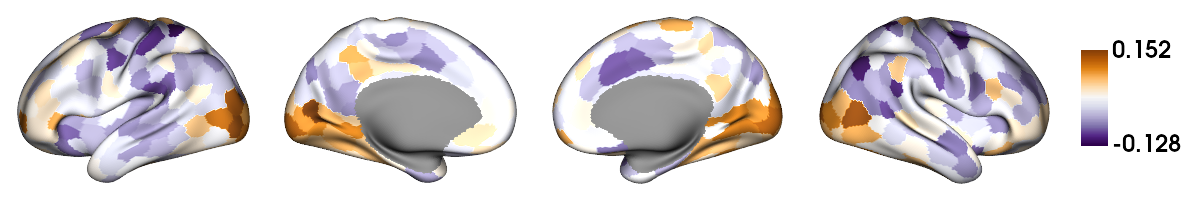

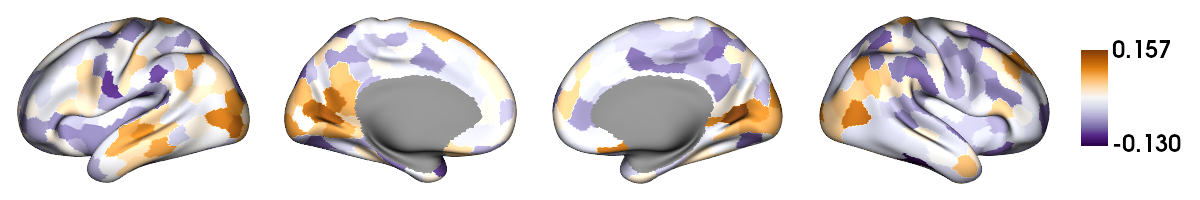

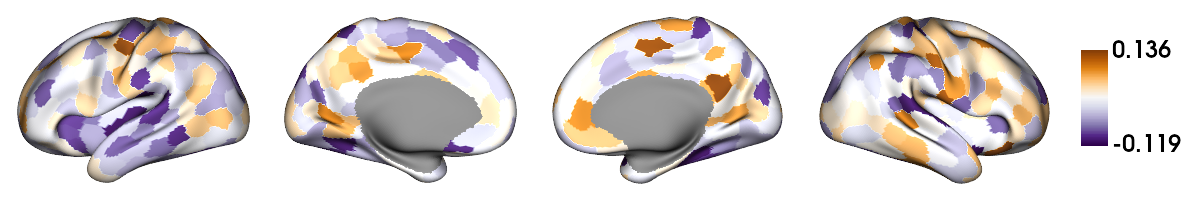

In [97]:
from IPython.display import Image, display
import numpy as np

# Loop through all gradients in the PLS results
for grad_name in results.keys():
    X_saliences = results[grad_name]['X_saliences']  # LV1 only

    # Create brain map with NaNs everywhere except labeled parcels
    brain_map = np.full_like(atlas, np.nan, dtype=float)
    for j in range(len(X_saliences)):
        brain_map[atlas == j + 1] = X_saliences[j]
    brain_map[atlas == 0] = np.nan

    # Save filename
    filename = f'./new_figures/{grad_name}_LC1_map_cortex.png'

    # Plot cortical surface (using your custom plotting function `fp.plot_surface`)
    fp.plot_surface(
        data=[brain_map],
        size=(1200, 200),
        cmap='PuOr_r',
        display=False,  # Save instead of showing interactively
        filename=filename
    )

    # Display the saved image
    display(Image(filename))


## Permutation testing

In [98]:
import numpy as np
from sklearn.cross_decomposition import PLSRegression

# -------------------------------
# Permutation testing parameters
# -------------------------------
n_permutations = 15000  # number of permutations
n_components = 1         # LV1 only
results_perm = {}        # store permutation p-values

# Loop over gradients (G1, G2, G3)
for grad_name in results.keys():
    print(f"Permutation testing for {grad_name}...")

    # Retrieve standardized X and Y
    X = results[grad_name]['X_std']  # standardized X (brain data)
    Y = results[grad_name]['Y_std']  # standardized Y (behavioral data)

    # Fit original PLS to get observed singular value
    pls = PLSRegression(n_components=n_components)
    pls.fit(X, Y)
    # Observed covariance for LV1
    X_scores = pls.x_scores_[:, 0]
    Y_scores = pls.y_scores_[:, 0]
    obs_singular_value = np.cov(X_scores, Y_scores, bias=True)[0, 1]  # covariance

    # -----------------------
    # Run permutations
    # -----------------------
    perm_singular_values = np.zeros(n_permutations)
    for i in range(n_permutations):
        # Shuffle rows of X
        X_perm = X[np.random.permutation(X.shape[0]), :]
        pls_perm = PLSRegression(n_components=n_components)
        pls_perm.fit(X_perm, Y)
        X_scores_perm = pls_perm.x_scores_[:, 0]
        Y_scores_perm = pls_perm.y_scores_[:, 0]
        # Compute covariance for LV1
        perm_singular_values[i] = np.cov(X_scores_perm, Y_scores_perm, bias=True)[0, 1]

    # Compute p-value: proportion of permuted covariances >= observed
    p_value = np.mean(perm_singular_values >= obs_singular_value)

    # Store results
    results_perm[grad_name] = {
        'obs_singular_value': obs_singular_value,
        'perm_singular_values': perm_singular_values,
        'p_values': p_value
    }

    print(f"{grad_name} LV1 permutation p-value: {p_value:.4f}")



Permutation testing for G1...
G1 LV1 permutation p-value: 0.0541
Permutation testing for G2...


c:\Users\ferraras\AppData\Local\miniforge3\envs\gradient\lib\site-packages\sklearn\cross_decomposition\_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


G2 LV1 permutation p-value: 0.5545
Permutation testing for G3...
G3 LV1 permutation p-value: 0.8107


Permutation testing for G1...


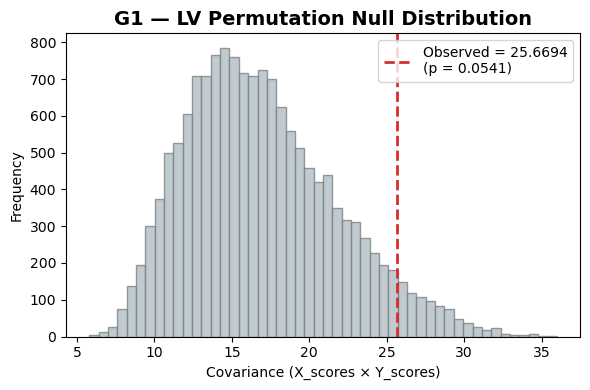

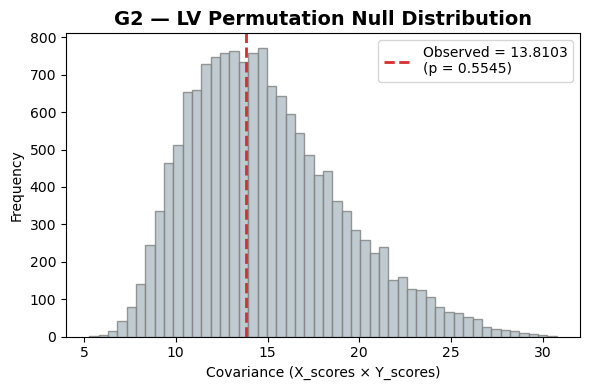

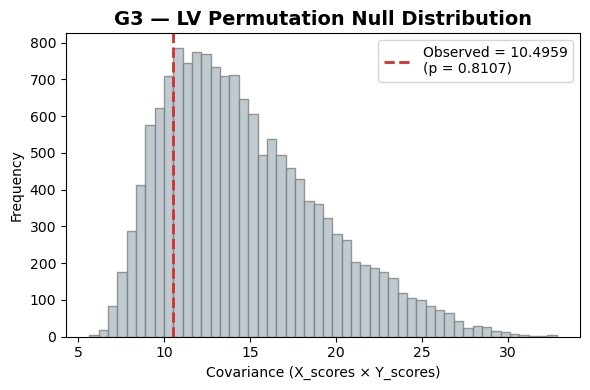

Permutation testing for G2...


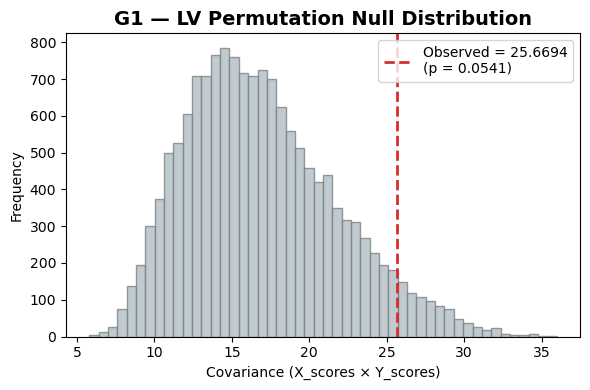

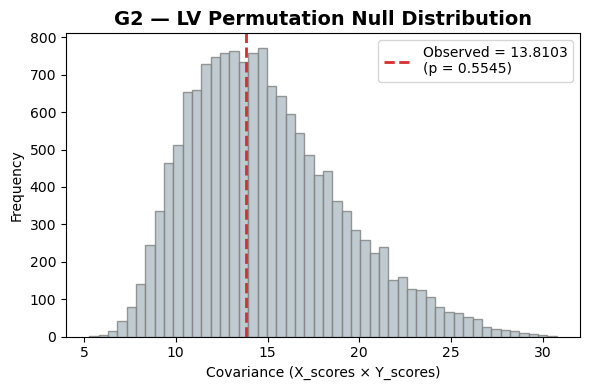

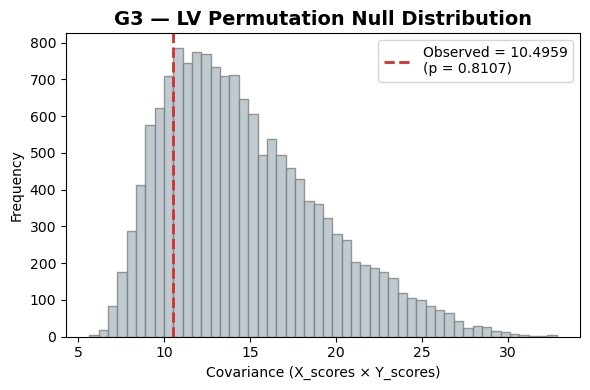

Permutation testing for G3...


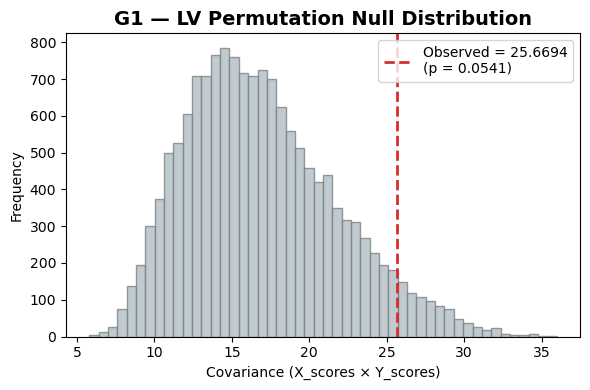

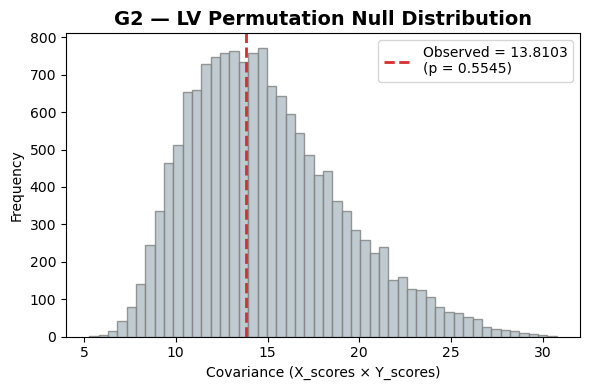

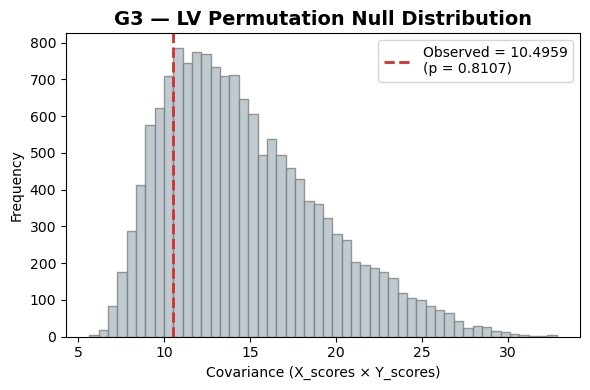

✅ Permutation histograms saved to 'new_figures/' and displayed.


In [99]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Create folder for output figures
os.makedirs("new_figures", exist_ok=True)
for grad_name in results.keys():
    print(f"Permutation testing for {grad_name}...")
    res_perm = results_perm[grad_name]
# Plot permutation null distributions per LV and gradient
    for grad_name, res_perm in results_perm.items():
        obs_vals = res_perm['obs_singular_value']
        perm_vals = res_perm['perm_singular_values']
        p_vals = res_perm['p_values']

        plt.figure(figsize=(6, 4))
        plt.hist(perm_vals, bins=50, color="#B0BEC5", edgecolor="gray", alpha=0.8)
        plt.axvline(obs_vals, color="#D32F2F", linestyle="--", linewidth=2,
                        label=f"Observed = {obs_vals:.4f}\n(p = {p_vals:.4f})")
        plt.title(f"{grad_name} — LV Permutation Null Distribution", fontsize=14, fontweight="bold")
        plt.xlabel("Covariance (X_scores × Y_scores)")
        plt.ylabel("Frequency")
        plt.legend()
        plt.tight_layout()
            # Save figure
        plt.savefig(f"new_figures/{grad_name}_LV_permutation_hist.png", dpi=300)
            # Show figure
        plt.show()
            # Optionally close to free memory (can skip if you want it open)
        plt.close()

print("✅ Permutation histograms saved to 'new_figures/' and displayed.")


## Bootstrap resampling

Bootstrap resampling for G1...


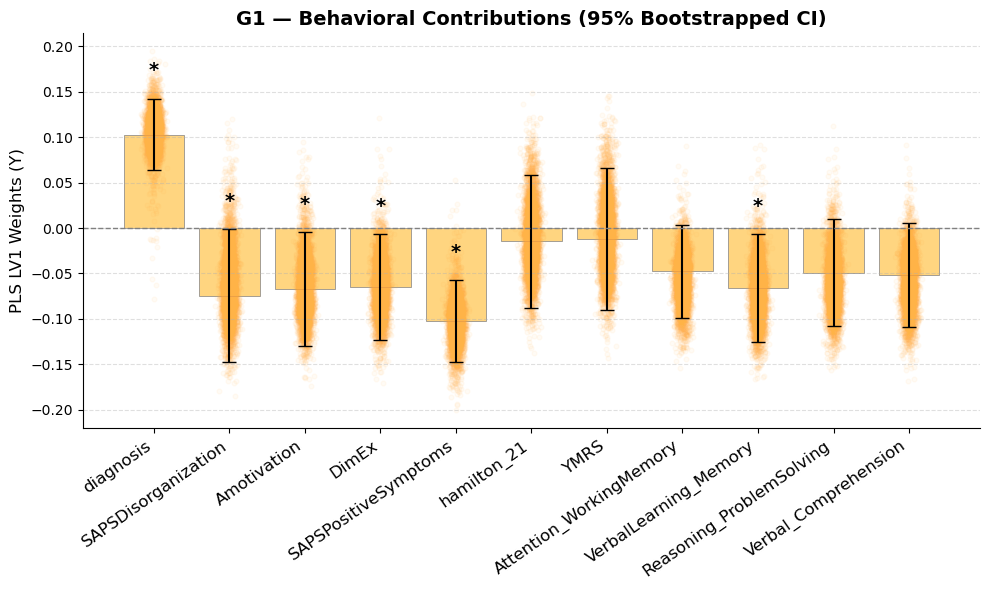

Bootstrap resampling for G2...


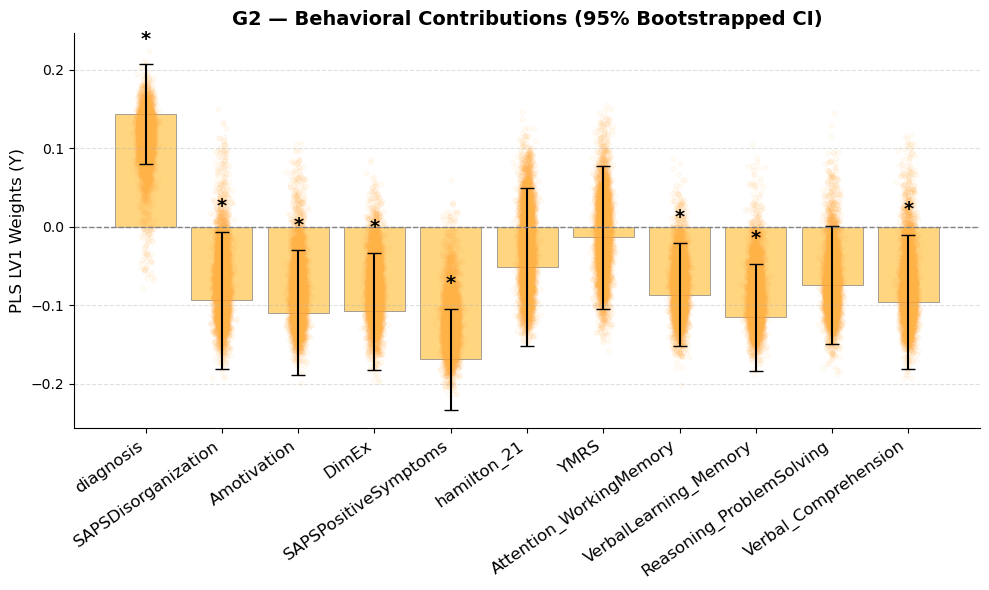

Bootstrap resampling for G3...


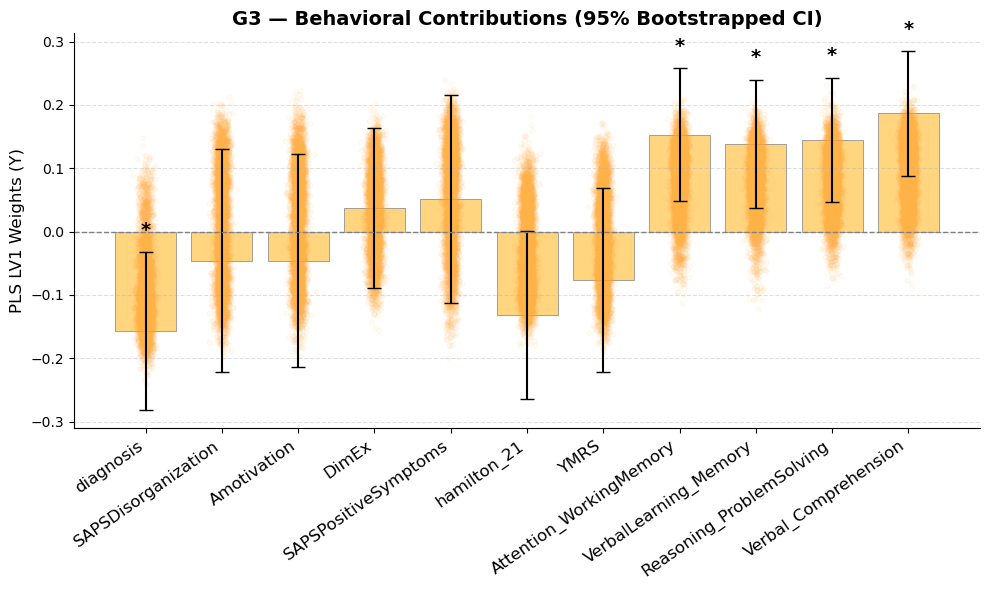

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# -------------------------------
# Bootstrap parameters
# -------------------------------
n_bootstrap = 5000  # number of bootstrap resamples
n_components = 1     # LV1 only
results_boot = {}    # store bootstrap ratios

# Color palette for plotting
bar_color = '#FFD580'
point_color = '#FFB347'
star_color = 'black'

# -------------------------------
# Loop over gradients
# -------------------------------
for grad_name, res in results.items():
    print(f"Bootstrap resampling for {grad_name}...")

    # Standardized X and Y
    X = res['X_std']
    Y = res['Y_std']
    n_subjects, n_voxels = X.shape
    n_behav = Y.shape[1]

    # Original PLS to get original weights
    pls_orig = PLSRegression(n_components=n_components)
    pls_orig.fit(X, Y)
    X_orig_weights = pls_orig.x_weights_[:, 0]
    Y_orig_weights = pls_orig.y_weights_[:, 0]

    # -----------------------
    # Bootstrap resampling
    # -----------------------
    X_boot_weights = np.zeros((n_bootstrap, n_voxels))
    Y_boot_weights = np.zeros((n_bootstrap, n_behav))

    for i in range(n_bootstrap):
        # Resample subjects with replacement
        Xb, Yb = resample(X, Y, n_samples=n_subjects, replace=True)

        pls_boot = PLSRegression(n_components=n_components)
        pls_boot.fit(Xb, Yb)
        Xb_weights = pls_boot.x_weights_[:, 0]
        Yb_weights = pls_boot.y_weights_[:, 0]

        # -----------------------
        # Sign-flipping correction
        # -----------------------

        # Align bootstrap LV1 with original LV1
        if np.dot(Xb_weights, X_orig_weights) < 0:
            Xb_weights *= -1
            Yb_weights *= -1

        X_boot_weights[i, :] = Xb_weights
        Y_boot_weights[i, :] = Yb_weights

    # -----------------------
    # Compute bootstrap ratios
    # -----------------------
    X_bsr = X_orig_weights / X_boot_weights.std(axis=0)
    Y_bsr = Y_orig_weights / Y_boot_weights.std(axis=0)

    results_boot[grad_name] = {
        'X_bsr': X_bsr,
        'Y_bsr': Y_bsr,
        'X_boot_weights': X_boot_weights,
        'Y_boot_weights': Y_boot_weights
    }

    # -----------------------
    # Behavioral bar plot visualization
    # -----------------------
    
    # Mean and 95% CI
    y_mean = Y_orig_weights
    y_sd = Y_boot_weights.std(axis=0)
    lower_ci = y_mean - 1.96 * y_sd
    upper_ci = y_mean + 1.96 * y_sd

    # Determine significance
    significant = (lower_ci > 0) | (upper_ci < 0)

    Y_cols = list(res['behav_corrs'].keys())
    fig, ax = plt.subplots(figsize=(10,6))

    # Bars with error bars
    bars = ax.bar(np.arange(n_behav), y_mean,
                  width=0.8,
                  yerr=[y_mean - lower_ci, upper_ci - y_mean],
                  capsize=5, color=bar_color, edgecolor='gray', linewidth=0.5)

    # Overlay bootstrap points
    for j in range(n_behav):
        x = np.random.normal(j, 0.05, size=n_bootstrap)
        ax.scatter(x, Y_boot_weights[:, j], color=point_color, alpha=0.05, s=12)

    # Zero line
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)

    # Significance stars
    for j, sig in enumerate(significant):
        if sig:
            ax.text(j, upper_ci[j] + 0.02, "*", ha='center', va='bottom',
                    fontsize=14, color=star_color, fontweight='bold')

    # Labels
    ax.set_xticks(np.arange(n_behav))
    ax.set_xticklabels(Y_cols, rotation=35, ha='right', fontsize=12)
    ax.set_ylabel('PLS LV1 Weights (Y)', fontsize=12)
    ax.set_title(f'{grad_name} — Behavioral Contributions (95% Bootstrapped CI)', fontsize=14, fontweight='bold')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.xaxis.grid(False)

    plt.tight_layout()
    plt.show()


## Variance explained

Computing variance explained for G1...
  LV1 explains 8.90% of X variance, 11.08% of Y variance, and 14.98% shared variance.

Computing variance explained for G2...
  LV1 explains 5.11% of X variance, 15.05% of Y variance, and 4.33% shared variance.

Computing variance explained for G3...
  LV1 explains 3.81% of X variance, 14.76% of Y variance, and 2.50% shared variance.



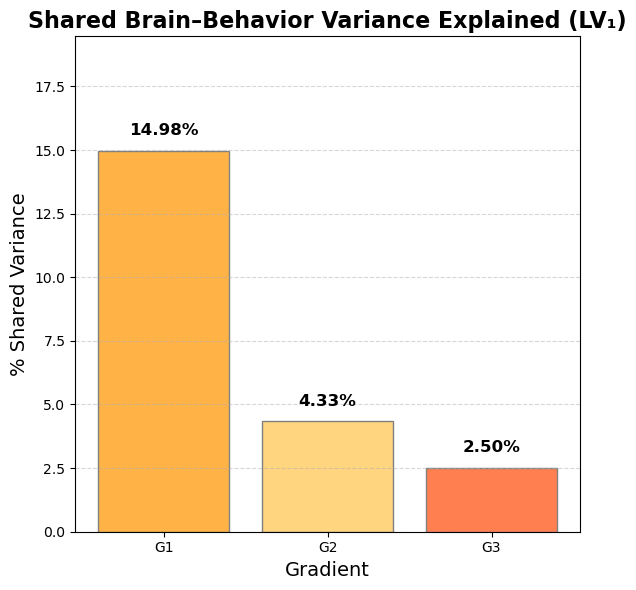

In [101]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression

var_explained_dict = {}

for grad_name, res in results.items():
    print(f"Computing variance explained for {grad_name}...")

    X = res['X_std']
    Y = res['Y_std']

    pls = PLSRegression(n_components=1)
    pls.fit(X, Y)

    # Reconstruct predicted X and Y
    X_pred = pls.x_scores_ @ pls.x_loadings_.T
    Y_pred = pls.x_scores_ @ pls.y_loadings_.T

    # Variance explained within each block
    var_X = np.var(X, axis=0).sum()
    var_Y = np.var(Y, axis=0).sum()
    var_X_expl = np.var(X_pred, axis=0).sum() / var_X
    var_Y_expl = np.var(Y_pred, axis=0).sum() / var_Y

    # Shared cross-covariance variance explained
    shared_var = (pls.x_scores_.T @ pls.y_scores_)**2 / (np.sum(X**2) * np.sum(Y**2))
    shared_var = shared_var.item() 

    res['var_X_expl'] = var_X_expl
    res['var_Y_expl'] = var_Y_expl
    res['shared_var'] = shared_var

    var_explained_dict[grad_name] = {
        'X_var%': var_X_expl * 100,
        'Y_var%': var_Y_expl * 100,
        'Shared%': shared_var * 100
    }

    print(f"  LV1 explains {var_X_expl * 100:.2f}% of X variance, "
          f"{var_Y_expl * 100:.2f}% of Y variance, "
          f"and {shared_var * 100:.2f}% shared variance.\n")

# --- Plot Shared Variance Explained ---
grad_names = list(var_explained_dict.keys())
vals = [v['Shared%'] for v in var_explained_dict.values()]

plt.figure(figsize=(6, 6))
bars = plt.bar(grad_names, vals, color=['#FFB347', '#FFD580', '#FF7F50'], edgecolor='gray')

for i, v in enumerate(vals):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title("Shared Brain–Behavior Variance Explained (LV₁)", fontsize=16, fontweight='bold')
plt.ylabel("% Shared Variance", fontsize=14)
plt.xlabel("Gradient", fontsize=14)
plt.ylim(0, max(vals) * 1.3)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("new_figures/shared_variance_explained_LV1.png", dpi=300)
plt.show()


## New variance explained

1. Matrix-Based Shared Variance

What it measures:

- Think of the entire X–Y relationship as a big table showing how every brain region covaries with every behavioral score.
- LV₁ gives a partial reconstruction of this table.
- Matrix-based shared variance tells you: “How much of the total pattern of brain–behavior covariance is explained by LV₁?”

Key point:

- It considers all features in X and Y.
- If LV₁ captures only part of the table, the fraction < 100%.

2. Latent-Score–Based Shared Variance

What it measures:

- Instead of looking at all features, it just looks at the summary numbers for each subject: the latent scores t (brain) and u (behavior).
- Then it checks how much these two numbers co-vary.

Analogy: Imagine each subject has a single “brain score” and a single “behavior score” from LV₁. How strongly do these two scores move together across subjects? Latent-score metric = fraction of total covariance energy captured by just this one pair of summary scores.

Key point:

- This is a simpler, lower-dimensional view.
- Usually, it’s ≤ the matrix-based metric, because we’re ignoring all the other details of X and Y.

Computing variance explained for gradients-based PLS across all gradients...

G1:
  LV1 explains 8.90% of X variance, 11.08% of Y variance, 62.11% of total X–Y cross-covariance energy, and t-u squared correlation = 35.96%

G2:
  LV1 explains 5.11% of X variance, 15.05% of Y variance, 56.04% of total X–Y cross-covariance energy, and t-u squared correlation = 48.36%

G3:
  LV1 explains 3.81% of X variance, 14.76% of Y variance, 40.61% of total X–Y cross-covariance energy, and t-u squared correlation = 59.36%



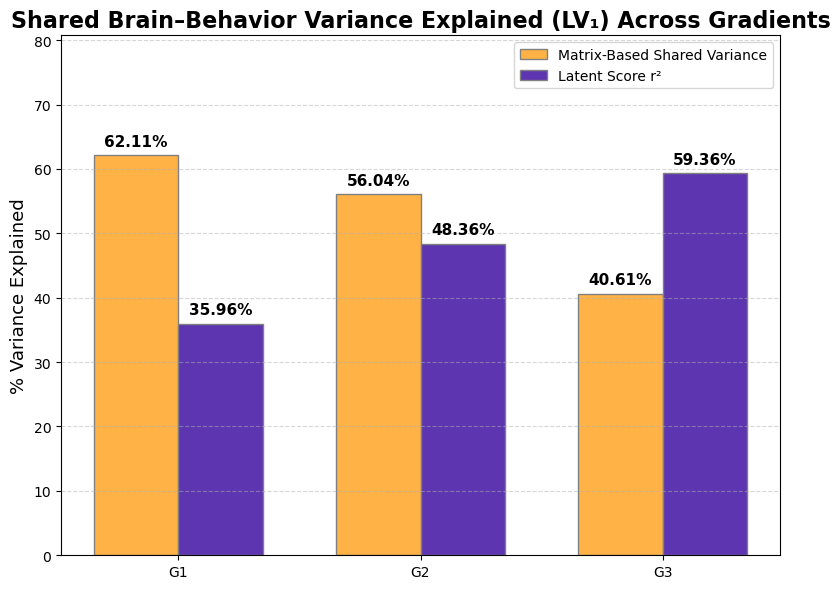

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
import os

os.makedirs("new_figures", exist_ok=True)

var_explained_dict = {}

print("Computing variance explained for gradients-based PLS across all gradients...\n")

for grad_name, res in results.items():

    X = res['X_std']
    Y = res['Y_std']
    n_samples = X.shape[0]

    pls = PLSRegression(n_components=1)
    pls.fit(X, Y)

    X_pred = pls.x_scores_ @ pls.x_loadings_.T
    Y_pred = pls.x_scores_ @ pls.y_loadings_.T

    var_X_expl = np.sum(X_pred**2) / np.sum(X**2)
    var_Y_expl = np.sum(Y_pred**2) / np.sum(Y**2)

    # Shared variance (matrix-based)
    C_full = (X.T @ Y) / (n_samples - 1)
    C_pred = (X_pred.T @ Y_pred) / (n_samples - 1)
    total_cross_energy = np.sum(C_full**2)
    explained_cross_energy = np.sum(C_pred**2)
    shared_var_matrix = 0.0 if total_cross_energy == 0 else explained_cross_energy / total_cross_energy

    # Latent scores squared correlation
    t = pls.x_scores_[:, 0]
    u = pls.y_scores_[:, 0]
    r2_latent = np.corrcoef(t, u)[0, 1]**2

    # Store results
    res['var_X_expl'] = var_X_expl
    res['var_Y_expl'] = var_Y_expl
    res['shared_var_matrix'] = shared_var_matrix
    res['r2_latent'] = r2_latent

    var_explained_dict[grad_name] = {
        'X_var%': var_X_expl * 100,
        'Y_var%': var_Y_expl * 100,
        'Shared_matrix%': shared_var_matrix * 100,
        'r2_latent%': r2_latent * 100
    }

    print(f"{grad_name}:")
    print(f"  LV1 explains {var_X_expl*100:.2f}% of X variance, "
          f"{var_Y_expl*100:.2f}% of Y variance, "
          f"{shared_var_matrix*100:.2f}% of total X–Y cross-covariance energy, "
          f"and t-u squared correlation = {r2_latent*100:.2f}%\n")

# --- Combined plot for all gradients ---
grad_names = list(var_explained_dict.keys())
matrix_vals = [v['Shared_matrix%'] for v in var_explained_dict.values()]
latent_vals = [v['r2_latent%'] for v in var_explained_dict.values()]

x = np.arange(len(grad_names))
width = 0.35  # width of the bars

plt.figure(figsize=(8, 6))
plt.bar(x - width/2, matrix_vals, width, label='Matrix-Based Shared Variance', color='#FFB347', edgecolor='gray')
plt.bar(x + width/2, latent_vals, width, label='Latent Score r²', color='#5E35B1', edgecolor='gray')

# Add value labels
for i in range(len(grad_names)):
    plt.text(x[i] - width/2, matrix_vals[i] + 1, f"{matrix_vals[i]:.2f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')
    plt.text(x[i] + width/2, latent_vals[i] + 1, f"{latent_vals[i]:.2f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.xticks(x, grad_names)
plt.ylabel("% Variance Explained", fontsize=13)
plt.title("Shared Brain–Behavior Variance Explained (LV₁) Across Gradients", fontsize=16, fontweight='bold')
plt.ylim(0, max(max(matrix_vals), max(latent_vals)) * 1.3)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("new_figures/shared_variance_combined_LV1.png", dpi=300)
plt.show()


## Cross validation

In [103]:
import numpy as np
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold, LeaveOneOut
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# --------------------------------------------------
# PARAMETERS
# --------------------------------------------------
n_splits = 5        # for larger samples
n_repeats = 20      # number of random splits for KFold
n_perm = 1000       # number of permutations
random_state = 42

cv_results = {}

# --------------------------------------------------
# CROSS-VALIDATION LOOP
# --------------------------------------------------
for grad_name, res in results.items():
    print(f"\nCross-validating {grad_name}...")

    X = res['X_std']
    Y = res['Y_std']
    n = X.shape[0]

    # Choose CV strategy automatically
    if n < 80:
        print(f"  Small sample detected (n={n}) → using Leave-One-Out CV.")
        use_loocv = True
        n_repeats_eff = 1
    else:
        print(f"  Using {n_splits}-fold CV with {n_repeats} repeats.")
        use_loocv = False
        n_repeats_eff = n_repeats

    # ---------------------------
    # Collect predicted scores
    # ---------------------------
    all_x_pred = np.zeros(n)
    all_y_pred = np.zeros(n)

    if use_loocv:
        # LOOCV
        for test_idx in range(n):
            train_idx = np.setdiff1d(np.arange(n), test_idx)
            pls = PLSRegression(n_components=1)
            pls.fit(X[train_idx], Y[train_idx])

            all_x_pred[test_idx] = X[test_idx] @ pls.x_weights_[:, 0]
            all_y_pred[test_idx] = Y[test_idx] @ pls.y_weights_[:, 0]
    else:
        # KFold repeated CV
        temp_x_pred = np.zeros((n_repeats_eff, n))
        temp_y_pred = np.zeros((n_repeats_eff, n))

        for rep in range(n_repeats_eff):
            kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state + rep)
            for train_idx, test_idx in kf.split(X):
                pls = PLSRegression(n_components=1)
                pls.fit(X[train_idx], Y[train_idx])
                temp_x_pred[rep, test_idx] = X[test_idx] @ pls.x_weights_[:, 0]
                temp_y_pred[rep, test_idx] = Y[test_idx] @ pls.y_weights_[:, 0]
        # Average across repeats
        all_x_pred = temp_x_pred.mean(axis=0)
        all_y_pred = temp_y_pred.mean(axis=0)

    # ---------------------------
    # Compute observed correlation
    # ---------------------------
    observed_r, _ = pearsonr(all_x_pred, all_y_pred)
    print(f"  Observed out-of-sample correlation: r = {observed_r:.3f}")

    observed_r_new, _ = pearsonr(X_scores, Y_scores)
    print(f"  Observed LV correlation: r = {observed_r_new:.3f}")

    # ---------------------------
    # Permutation testing
    # ---------------------------
    perm_corrs = []
    for perm in range(n_perm):
        Y_perm = Y[np.random.permutation(n)]

        if use_loocv:
            perm_x_pred = np.zeros(n)
            perm_y_pred = np.zeros(n)
            for test_idx in range(n):
                train_idx = np.setdiff1d(np.arange(n), test_idx)
                pls = PLSRegression(n_components=1)
                pls.fit(X[train_idx], Y_perm[train_idx])
                perm_x_pred[test_idx] = X[test_idx] @ pls.x_weights_[:, 0]
                perm_y_pred[test_idx] = Y_perm[test_idx] @ pls.y_weights_[:, 0]
        else:
            temp_x_pred = np.zeros((n_repeats_eff, n))
            temp_y_pred = np.zeros((n_repeats_eff, n))
            for rep in range(n_repeats_eff):
                kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state + rep)
                for train_idx, test_idx in kf.split(X):
                    pls = PLSRegression(n_components=1)
                    pls.fit(X[train_idx], Y_perm[train_idx])
                    temp_x_pred[rep, test_idx] = X[test_idx] @ pls.x_weights_[:, 0]
                    temp_y_pred[rep, test_idx] = Y_perm[test_idx] @ pls.y_weights_[:, 0]
            perm_x_pred = temp_x_pred.mean(axis=0)
            perm_y_pred = temp_y_pred.mean(axis=0)

        r_perm, _ = pearsonr(perm_x_pred, perm_y_pred)
        perm_corrs.append(r_perm)

    perm_corrs = np.array(perm_corrs)
    pval = np.mean(perm_corrs >= observed_r)

    cv_results[grad_name] = {
        'observed_r': observed_r,
        'perm_corrs': perm_corrs,
        'pval': pval
    }

    print(f"  → Cross-validated correlation p-value = {pval:.4f}")

# --------------------------------------------------
# PLOT RESULTS
# --------------------------------------------------
plt.figure(figsize=(7, 6))
bars = plt.bar(cv_results.keys(),
               [cv_results[g]['observed_r'] for g in cv_results],
               color=['#FFB347', '#FFD580', '#FF7F50'],
               edgecolor='gray')
plt.ylabel("Mean Out-of-Sample Correlation (r)", fontsize=14)
plt.title("Cross-Validated Brain–Behavior Correlations (LV₁)", fontsize=15, fontweight='bold')

for i, g in enumerate(cv_results.keys()):
    r = cv_results[g]['observed_r']
    p = cv_results[g]['pval']
    plt.text(i, r + 0.01, f"p={p:.3f}", ha='center', fontsize=12)

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig("new_figures/cv_out_of_sample_correlations.png", dpi=300)
plt.show()



Cross-validating G1...
  Small sample detected (n=73) → using Leave-One-Out CV.
  Observed out-of-sample correlation: r = 0.296
  Observed LV correlation: r = 0.770


c:\Users\ferraras\AppData\Local\miniforge3\envs\gradient\lib\site-packages\sklearn\cross_decomposition\_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


  → Cross-validated correlation p-value = 0.0240

Cross-validating G2...
  Small sample detected (n=73) → using Leave-One-Out CV.
  Observed out-of-sample correlation: r = 0.089
  Observed LV correlation: r = 0.770


c:\Users\ferraras\AppData\Local\miniforge3\envs\gradient\lib\site-packages\sklearn\cross_decomposition\_pls.py:104: ConvergenceWarning: Maximum number of iterations reached
  warnings.warn("Maximum number of iterations reached", ConvergenceWarning)


  → Cross-validated correlation p-value = 0.3290

Cross-validating G3...
  Small sample detected (n=73) → using Leave-One-Out CV.
  Observed out-of-sample correlation: r = -0.203
  Observed LV correlation: r = 0.770


KeyboardInterrupt: 

## Split half resampling

In [ ]:
import numpy as np
from sklearn.cross_decomposition import PLSRegression

n_splits = 100  # number of random split-half resamplings
stability_results = {}

for grad_name, res in results.items():
    print(f"\nSplit-half resampling for {grad_name}...")

    X = res['X_std']
    Y = res['Y_std']
    n = X.shape[0]

    brain_corrs = []
    behav_corrs = []

    for split in range(n_splits):
        # Random split
        idx = np.random.permutation(n)
        half = n // 2
        idx1, idx2 = idx[:half], idx[half:]

        # PLS on first half
        pls1 = PLSRegression(n_components=1)
        pls1.fit(X[idx1], Y[idx1])
        U1 = pls1.x_weights_[:, 0]
        V1 = pls1.y_weights_[:, 0]

        # PLS on second half
        pls2 = PLSRegression(n_components=1)
        pls2.fit(X[idx2], Y[idx2])
        U2 = pls2.x_weights_[:, 0]
        V2 = pls2.y_weights_[:, 0]

        # Align signs
        if np.dot(U1, U2) < 0:
            U2 *= -1
            V2 *= -1

        # Compute correlation
        brain_corrs.append(np.corrcoef(U1, U2)[0, 1])
        behav_corrs.append(np.corrcoef(V1, V2)[0, 1])

    stability_results[grad_name] = {
        'brain_stability': np.mean(brain_corrs),
        'behav_stability': np.mean(behav_corrs),
        'brain_corrs_all': brain_corrs,
        'behav_corrs_all': behav_corrs
    }

    print(f"  Brain pattern stability (mean r): {stability_results[grad_name]['brain_stability']:.3f}")
    print(f"  Behavioral pattern stability (mean r): {stability_results[grad_name]['behav_stability']:.3f}")



Split-half resampling for G1...
  Brain pattern stability (mean r): 0.291
  Behavioral pattern stability (mean r): 0.745

Split-half resampling for G2...
  Brain pattern stability (mean r): 0.082
  Behavioral pattern stability (mean r): 0.406

Split-half resampling for G3...
  Brain pattern stability (mean r): 0.070
  Behavioral pattern stability (mean r): -0.283


# Gradients PLS train & test

In [104]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

### Data loading + preprocessing + train & test PLS

In [105]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------
# Helper functions
# ------------------------
def ensure_numeric_encoding(df, col):
    if not np.issubdtype(df[col].dtype, np.number):
        mapping = {k: i for i, k in enumerate(df[col].unique())}
        print(f"Auto-mapped '{col}': {mapping}")
        df[col] = df[col].map(mapping)
    return df

def regress_out(X, covariates):
    X_resid = np.zeros_like(X)
    for j in range(X.shape[1]):
        model = LinearRegression().fit(covariates, X[:, j])
        X_resid[:, j] = X[:, j] - model.predict(covariates)
    return X_resid

def r_p_text(x, y):
    r, p = pearsonr(x, y)
    if p < 0.001:
        return r, 'P < 0.001'
    else:
        return r, f'P = {p:.3f}'

# ------------------------
# Define gradients and variables
# ------------------------
grad_files = ['./g1_aligned_cog.csv', './g2_aligned_cog.csv', './g3_aligned_cog.csv']
grad_names = ['G1', 'G2', 'G3']

group_definitions = {
    'Attention_WorkingMemory': ['Digit_span_forward', 'Digit_span_backward', 'Digit_span_sequencing', 'Letter_number_sequencing'],
    'VerbalLearning_Memory': ['Long_free_recall', 'Short_free_recall', 'Free_recall_correct'],
    'Reasoning_ProblemSolving': ['Matrix_Reasoning'],
    'Verbal_Comprehension': ['Vocabulary']
}

other_vars = ['diagnosis', 'SAPSDisorganization', 'Amotivation', 'DimEx',
              'SAPSPositiveSymptoms', 'hamilton_21', 'YMRS']
covariate_cols = ['age', 'gender']

# ------------------------
# Pipeline parameters
# ------------------------
n_splits = 100
results = {}
pls_models = []
x_train_list = []
y_train_list = []
x_test_list = []
y_test_list = []

# ------------------------
# Main PLS pipeline
# ------------------------
for grad_file, grad_name in zip(grad_files, grad_names):
    print(f"\n--- Processing {grad_name} ---")
    df = pd.read_csv(grad_file)
    
    # Keep patients only
    df = df[df['diagnosis'].isin([2, 3])].copy()
    
    # Encode categorical
    for col in ['gender', 'diagnosis']:
        df = ensure_numeric_encoding(df, col)
    
    # Brain parcels (X)
    parcel_cols = [f'node_{i+1}' for i in range(400)]
    X = df[parcel_cols].values
    
    # Behavioral domains (Y)
    for group_name, var_list in group_definitions.items():
        zscored = df[var_list].apply(lambda x: (x-x.mean())/x.std(), axis=0)
        df[group_name] = -zscored.mean(axis=1)  # invert: higher = worse
    
    Y_cols = other_vars + list(group_definitions.keys())
    Y = df[Y_cols].values
    
    # Remove missing data
    valid_mask = ~(np.isnan(X).any(axis=1) | np.isnan(Y).any(axis=1))
    X = X[valid_mask]
    Y = Y[valid_mask]
    covars = df.loc[valid_mask, covariate_cols].values
    
    # Regress out covariates from X
    X_resid = regress_out(X, covars)
    
    # Standardize
    X_std = StandardScaler().fit_transform(X_resid)
    Y_std = StandardScaler().fit_transform(Y)
    
    # ------------------------
    # Cross-validation: generate splits
    # ------------------------
    n_subjects = X_std.shape[0]
    splits = np.random.randint(0, 2, size=(n_splits, n_subjects))
    
    r_train = np.zeros(n_splits)
    r_test  = np.zeros(n_splits)
    
    for j in range(n_splits):
        train_idx = splits[j]==0
        test_idx  = splits[j]==1
        
        X_train, Y_train = X_std[train_idx], Y_std[train_idx]
        X_test,  Y_test  = X_std[test_idx],  Y_std[test_idx]
        
        pls = PLSRegression(n_components=1)
        pls.fit(X_train, Y_train)
        x_tr, y_tr = pls.transform(X_train, Y_train)
        x_te, y_te = pls.transform(X_test, Y_test)
        
        r_train[j] = pearsonr(x_tr[:,0], y_tr[:,0])[0]
        r_test[j]  = pearsonr(x_te[:,0], y_te[:,0])[0]
    
    # ------------------------
    # Select best split
    # ------------------------
    rank = (r_train - r_test)/r_train
    rank[r_test>r_train] = rank.min()
    best_split = rank.argmin()
    
    # ------------------------
    # Refit PLS on best split
    # ------------------------
    train_idx = splits[best_split]==0
    test_idx  = splits[best_split]==1
    X_train, Y_train = X_std[train_idx], Y_std[train_idx]
    X_test,  Y_test  = X_std[test_idx],  Y_std[test_idx]
    
    pls = PLSRegression(n_components=1)
    pls.fit(X_train, Y_train)
    
    x_tr, y_tr = pls.transform(X_train, Y_train)
    x_te, y_te = pls.transform(X_test, Y_test)
    
    # Store results
    results[grad_name] = {
        'X_scores': X_train,
        'Y_scores': Y_train,
        'x_train': x_tr,
        'y_train': y_tr,
        'x_test': x_te,
        'y_test': y_te,
        'X_saliences': pls.x_weights_[:,0],
        'Y_saliences': pls.y_weights_[:,0],
        'behav_corrs': {var: pearsonr(Y_train[:,i], y_tr[:,0])[0] for i,var in enumerate(Y_cols)},
        'best_split': best_split
    }
    
    # Save for plotting
    x_train_list.append(x_tr)
    y_train_list.append(y_tr)
    x_test_list.append(x_te)
    y_test_list.append(y_te)
    pls_models.append(pls)
    
print("\nAll gradients processed. Results stored in `results` dict.")



--- Processing G1 ---

--- Processing G2 ---

--- Processing G3 ---

All gradients processed. Results stored in `results` dict.


### Train vs Test performance boxplots

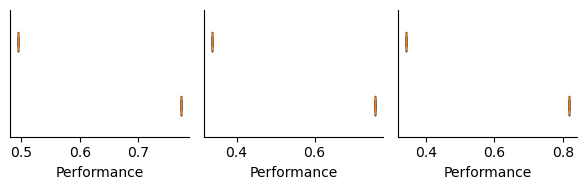

In [106]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

grad_names = ['G1', 'G2', 'G3']
r_train = np.zeros((3, 100))
r_test  = np.zeros((3, 100))

# Compute correlations for all splits stored in results
for i, grad in enumerate(grad_names):
    x_tr = results[grad]['x_train']
    y_tr = results[grad]['y_train']
    x_te = results[grad]['x_test']
    y_te = results[grad]['y_test']
    
    r_train[i, :] = [pearsonr(x_tr[:,0], y_tr[:,0])[0]]*100
    r_test[i, :]  = [pearsonr(x_te[:,0], y_te[:,0])[0]]*100

# Boxplot
fig, ax = plt.subplots(1, 3, figsize=(6, 2))
for i in range(3):
    ax[i].boxplot([r_train[i], r_test[i]], widths=0.3, sym='', vert=False)
    ax[i].set_xlabel('Performance')
    ax[i].set_yticks([])
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)
fig.tight_layout()
plt.show()


### Model ranking

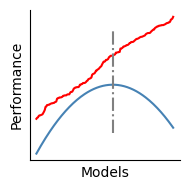

In [114]:
fig, ax = plt.subplots(1,1, figsize=(2,2))
x = np.random.randint(-200, 100, 180)  # example simulation

ax.plot(np.arange(-100, 80, 1), -x[x.argsort()][::-1]/20, color='red')
ax.plot(np.arange(-100, 80, 1), -(np.arange(-100,80,1)**2)/1000, color='steelblue')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.set_ylabel('Performance')
ax.set_xlabel('Models')
ax.vlines(x=0, ymin=-7, ymax=8, ls='-.', color='grey')

fig.tight_layout()
plt.show()


In [115]:
x_train_list_best = []
y_train_list_best = []
x_test_list_best  = []
y_test_list_best  = []

for i, grad in enumerate(grad_names):
    best_split = results[grad]['best_split']
    x_tr, y_tr = results[grad]['x_train'], results[grad]['y_train']
    x_te, y_te = results[grad]['x_test'], results[grad]['y_test']
    
    x_train_list_best.append(x_tr)
    y_train_list_best.append(y_tr)
    x_test_list_best.append(x_te)
    y_test_list_best.append(y_te)


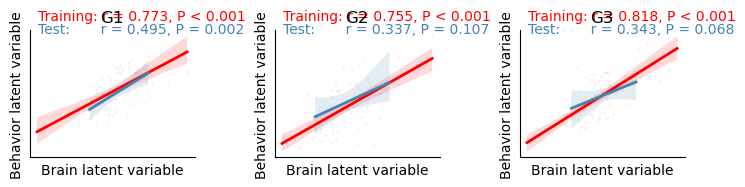

In [116]:
import seaborn as sns

fig, ax = plt.subplots(1,3, figsize=(7.5, 2))

for i, grad in enumerate(grad_names):
    # TRAIN
    sns.regplot(x=x_train_list_best[i][:,0], y=y_train_list_best[i][:,0],
                ax=ax[i],
                scatter_kws={'s':1, 'color':'red', 'alpha':0.05},
                line_kws={'lw':2, 'color':'red'})
    # TEST
    sns.regplot(x=x_test_list_best[i][:,0], y=y_test_list_best[i][:,0],
                ax=ax[i],
                scatter_kws={'s':1, 'color':'steelblue', 'alpha':0.05},
                line_kws={'lw':2, 'color':'steelblue'})
    
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['top'].set_visible(False)
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_xlabel('Brain latent variable')
    ax[i].set_ylabel('Behavior latent variable')
    ax[i].set_title(grad)
    
    r_tr, ptxt_tr = r_p_text(x_train_list_best[i][:,0], y_train_list_best[i][:,0])
    r_te, ptxt_te = r_p_text(x_test_list_best[i][:,0], y_test_list_best[i][:,0])
    
    ax[i].text(0.05, 1.08, f'Training: r = {r_tr:.3f}, {ptxt_tr}', transform=ax[i].transAxes, color='red')
    ax[i].text(0.05, 0.98, f'Test:       r = {r_te:.3f}, {ptxt_te}', transform=ax[i].transAxes, color='steelblue')

fig.tight_layout()
plt.show()


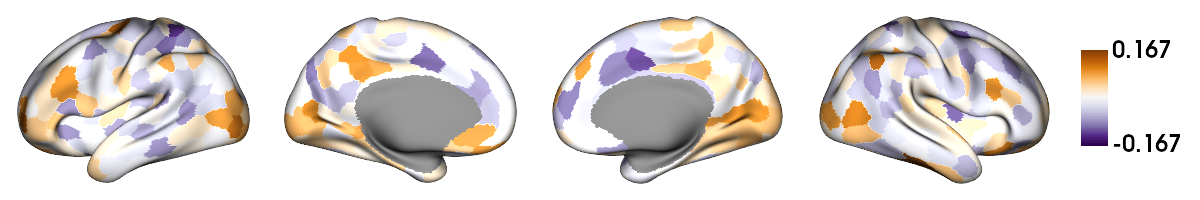

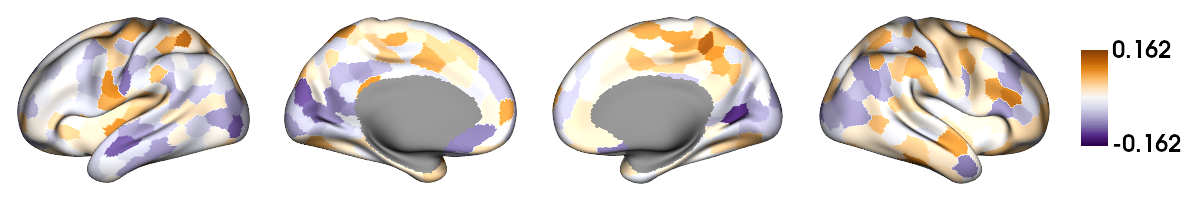

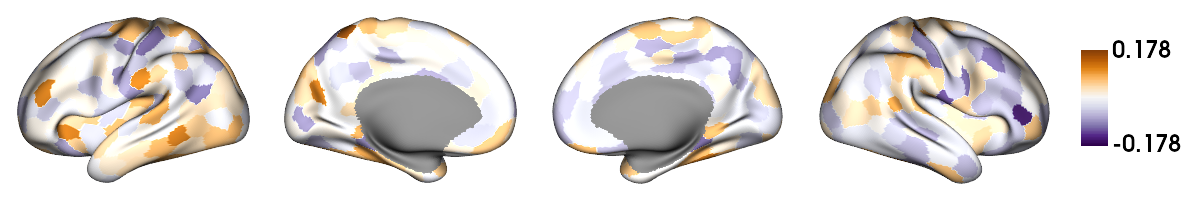

In [117]:
import os
from IPython.display import Image, display
import numpy as np

os.makedirs('./new_figures', exist_ok=True)

n_parcels = 400  # node_1 ... node_400

for grad_name in results.keys():
    X_sal = results[grad_name]['X_saliences']

    if len(X_sal) != n_parcels:
        raise ValueError(f'{grad_name}: Expected {n_parcels} saliences, got {len(X_sal)}')

    # Initialize surface map
    brain_map = np.full(atlas.shape, np.nan, dtype=float)

    # Assign parcel-wise saliences
    for parcel_id in range(1, n_parcels + 1):
        brain_map[atlas == parcel_id] = X_sal[parcel_id - 1]

    # Mask medial wall
    brain_map[atlas == 0] = np.nan

    # Optional: dynamic color range
    vmax = np.max(np.abs(X_sal))
    vmin = -vmax

    filename = f'./new_figures/{grad_name}_LV1_brain_saliences.png'

    fp.plot_surface(
        data=[brain_map],
        size=(1200, 200),  # adjust as needed
        cmap='PuOr_r',
        color_range=(vmin, vmax),
        display=False,
        filename=filename
    )

    display(Image(filename))


### Network level saliences

In [118]:
from matplotlib.colors import ListedColormap

lut = pd.read_csv('./BD-SCZ/Schaefer2018_400Parcels_7Networks_order_info.txt', header=None)
lut_color = np.array(lut.iloc[1::2])
lut_color = np.array([list(map(int, row[0].split())) for row in lut_color])
lut_color = lut_color[:,1:]
network_cmap = ListedColormap(lut_color/255)
lut_names = np.array(lut.iloc[::2])[:,0]
network=np.array([item[13:16] for item in lut_names])
network[network=='Vis'] = 1
network[network=='Som'] = 2
network[network=='Dor'] = 3
network[network=='Sal'] = 4
network[network=='Lim'] = 5
network[network=='Con'] = 6
network[network=='Def'] = 7
network = network.astype(int)
net_name = ['VIS', 'SMN', 'DAN', 'SN', 'LIM', 'FPN', 'DMN']
network

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4,

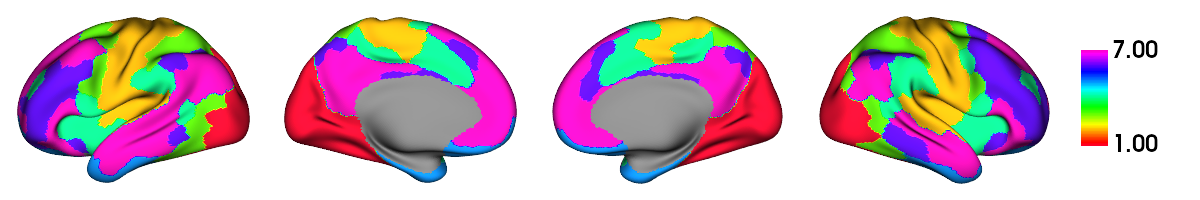

In [119]:
import numpy as np

grad_names = ['G1', 'G2', 'G3']
n_networks = 7

network_saliences = np.zeros((3, n_networks))

for i, grad in enumerate(grad_names):
    sal = results[grad]['X_saliences']  # shape (400,)

    for net in range(1, n_networks + 1):
        network_saliences[i, net-1] = np.mean(
            np.abs(sal[network == net])
        )
plot = atlas.copy().astype(float)
for i in range(400):
    plot[atlas == i+1] = network[i]
plot[atlas == 0] = np.nan

fp.plot_surface(
    data=[plot],
    size=(1200, 200),
    cmap='gist_rainbow',
    color_range=(1, 7),
    filename='./new_figures/schaefer7_networks.png',
    display=True
)


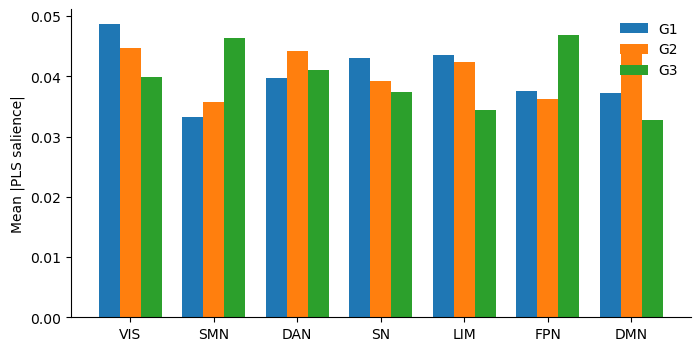

In [125]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(n_networks)

ax.bar(x - 0.25, network_saliences[0], width=0.25, label='G1')
ax.bar(x,         network_saliences[1], width=0.25, label='G2')
ax.bar(x + 0.25, network_saliences[2], width=0.25, label='G3')

ax.set_xticks(x)
ax.set_xticklabels(net_name)
ax.set_ylabel('Mean |PLS salience|')
ax.legend(frameon=False)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

#fig.tight_layout()
plt.show()
